In [ ]:
import sqlite3

# Creates a cloud-hosted database file named supply_chain.db
conn = sqlite3.connect('supply_chain.db')
cursor = conn.cursor()
cursor.execute("PRAGMA foreign_keys = ON;")

print("Initializing relational tables in the cloud...")

# 1. Create Distribution Centers Table
cursor.execute('''
CREATE TABLE IF NOT EXISTS distribution_centers (
    dc_id TEXT PRIMARY KEY,
    dc_name TEXT NOT NULL,
    city TEXT NOT NULL,
    region TEXT NOT NULL,
    capacity_status TEXT CHECK(capacity_status IN ('Optimal', 'Near Capacity', 'Overcapacity'))
);
''')

# 2. Create Route Metrics Table
cursor.execute('''
CREATE TABLE IF NOT EXISTS routes (
    route_id TEXT PRIMARY KEY,
    origin_city TEXT NOT NULL,
    destination_city TEXT NOT NULL,
    distance_miles INTEGER NOT NULL,
    estimated_hours INTEGER NOT NULL
);
''')

# 3. Create Core Transactional Orders Table
cursor.execute('''
CREATE TABLE IF NOT EXISTS orders (
    order_id TEXT PRIMARY KEY,
    dc_id TEXT,
    route_id TEXT,
    order_date TEXT NOT NULL,
    ship_date TEXT,
    actual_delivery_date TEXT,
    carrier_name TEXT,
    shipment_status TEXT CHECK(shipment_status IN ('Delivered', 'Delayed', 'Cancelled')),
    fuel_cost_usd REAL,
    FOREIGN KEY (dc_id) REFERENCES distribution_centers(dc_id),
    FOREIGN KEY (route_id) REFERENCES routes(route_id)
);
''')

conn.commit()
conn.close()
print("✅ Success: Cloud database schemas generated successfully.")


Initializing relational tables in the cloud...
✅ Success: Cloud database schemas generated successfully.


In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random

print("🚀 Simulating messy operations data...")

# 1. POPULATE LOOKUP DIMENSIONS
conn = sqlite3.connect('supply_chain.db')
cursor = conn.cursor()

dc_data = [
    ('DC-001', 'North Logistics Hub', 'Chicago', 'Midwest', 'Overcapacity'),
    ('DC-002', 'Pacific Freight Center', 'Seattle', 'West', 'Optimal'),
    ('DC-003', 'Southern Gateway', 'Dallas', 'South', 'Near Capacity'),
    ('DC-004', 'Atlantic Terminal', 'New York', 'East', 'Optimal')
]
cursor.executemany("INSERT OR REPLACE INTO distribution_centers VALUES (?, ?, ?, ?, ?)", dc_data)

route_data = [
    ('R-101', 'Chicago', 'New York', 800, 16),
    ('R-102', 'Seattle', 'Los Angeles', 1100, 22),
    ('R-103', 'Dallas', 'Atlanta', 800, 15),
    ('R-104', 'New York', 'Miami', 1300, 26),
    ('R-105', 'Chicago', 'Seattle', 2000, 40)
]
cursor.executemany("INSERT OR REPLACE INTO routes VALUES (?, ?, ?, ?, ?)", route_data)
conn.commit()

# 2. GENERATE MESSY RAW TRANSACTIONAL DATA (1000 Rows)
random.seed(42)
np.random.seed(42)
carriers = ['FedEx', 'Fed-Ex', 'fedex', 'UPS', 'ups', 'DHL Express', 'DHL', 'dhl']
statuses = ['Delivered', 'Delayed', 'Cancelled']
raw_orders = []
base_date = datetime(2026, 1, 1)

for i in range(1, 1001):
    order_id = f"ORD-{10000 + i}"
    dc = random.choice(dc_data)
    route = random.choice(route_data)
    order_days_offset = random.randint(0, 90)
    order_dt = base_date + timedelta(days=order_days_offset, hours=random.randint(0, 23))

    processing_hours = random.randint(4, 48) if dc[0] == 'DC-001' else random.randint(2, 12)
    ship_dt = order_dt + timedelta(hours=processing_hours)
    status = random.choices(statuses, weights=[0.80, 0.15, 0.05], k=1)[0]

    if status == 'Delivered':
        transit_variance = random.randint(-4, 4)
        actual_delivery_dt = ship_dt + timedelta(hours=route[4] + transit_variance)
    elif status == 'Delayed':
        transit_variance = random.randint(12, 72)
        actual_delivery_dt = ship_dt + timedelta(hours=route[4] + transit_variance)
    else:
        actual_delivery_dt = None

    if status == 'Delivered' and random.random() < 0.03:
        actual_delivery_dt = None

    fuel_cost = route[3] * random.uniform(0.5, 0.8)
    if random.random() < 0.04:
        fuel_cost = -fuel_cost # System error outlier

    raw_orders.append({
        'order_id': order_id, 'dc_id': dc[0], 'route_id': route[0],
        'order_date': order_dt.strftime('%Y-%m-%d %H:%M:%S'),
        'ship_date': ship_dt.strftime('%Y-%m-%d %H:%M:%S'),
        'actual_delivery_date': actual_delivery_dt.strftime('%Y-%m-%d %H:%M:%S') if actual_delivery_dt else None,
        'carrier_name': random.choice(carriers), 'shipment_status': status, 'fuel_cost_usd': fuel_cost
    })

df = pd.DataFrame(raw_orders)

# 3. PANDAS CLEANING PIPELINE
df['carrier_name'] = df['carrier_name'].str.upper().str.replace('-', ' ').replace({'DHL EXPRESS': 'DHL'})
df['fuel_cost_usd'] = df['fuel_cost_usd'].abs()

df['ship_date_dt'] = pd.to_datetime(df['ship_date'])
df['actual_delivery_date_dt'] = pd.to_datetime(df['actual_delivery_date'])
route_durations = {r[0]: r[4] for r in route_data}

def fix_missing_delivery_dates(row):
    if row['shipment_status'] == 'Delivered' and pd.isnull(row['actual_delivery_date_dt']):
        return row['ship_date_dt'] + timedelta(hours=route_durations.get(row['route_id'], 24))
    return row['actual_delivery_date_dt']

df['actual_delivery_date_dt'] = df.apply(fix_missing_delivery_dates, axis=1)
df['actual_delivery_date'] = df['actual_delivery_date_dt'].dt.strftime('%Y-%m-%d %H:%M:%S').fillna(np.nan)
df = df.drop(columns=['ship_date_dt', 'actual_delivery_date_dt'])

# 4. EXPORT TO SQL
df.to_sql('orders', conn, if_exists='append', index=False)
conn.close()
print("🎉 Success: Clean dataset generated and saved to the SQL database database.")


🚀 Simulating messy operations data...
🎉 Success: Clean dataset generated and saved to the SQL database database.


In [3]:
# Open connection to read data
conn = sqlite3.connect('supply_chain.db')

# Write your Carrier Reliability Performance SQL query
sql_query = """
WITH RouteDelayCTE AS (
    SELECT
        o.carrier_name,
        o.route_id,
        r.estimated_hours,
        -- Calculate actual transit hours using SQLite date arithmetic
        (julianday(o.actual_delivery_date) - julianday(o.ship_date)) * 24 AS actual_hours,
        o.fuel_cost_usd
    FROM orders o
    JOIN routes r ON o.route_id = r.route_id
    WHERE o.shipment_status = 'Delivered'
)
SELECT
    carrier_name,
    COUNT(*) AS total_shipments,
    ROUND(AVG(actual_hours - estimated_hours), 2) AS avg_hours_delay,
    ROUND(AVG(fuel_cost_usd), 2) AS avg_fuel_cost,
    RANK() OVER (ORDER BY AVG(actual_hours - estimated_hours) ASC) AS reliability_rank
FROM RouteDelayCTE
GROUP BY carrier_name;
"""

# Run query and pull results directly into a Pandas display dataframe
analysis_df = pd.read_sql_query(sql_query, conn)
conn.close()

# View your analytical output
analysis_df


,carrier_name,total_shipments,avg_hours_delay,avg_fuel_cost,reliability_rank
0,FED EX,99,-0.33,740.86,1
1,FEDEX,201,-0.09,806.45,2
2,DHL,285,-0.05,762.76,3
3,UPS,201,0.51,781.85,4


/tmp/ipykernel_1316/3272516305.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1316/3272516305.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


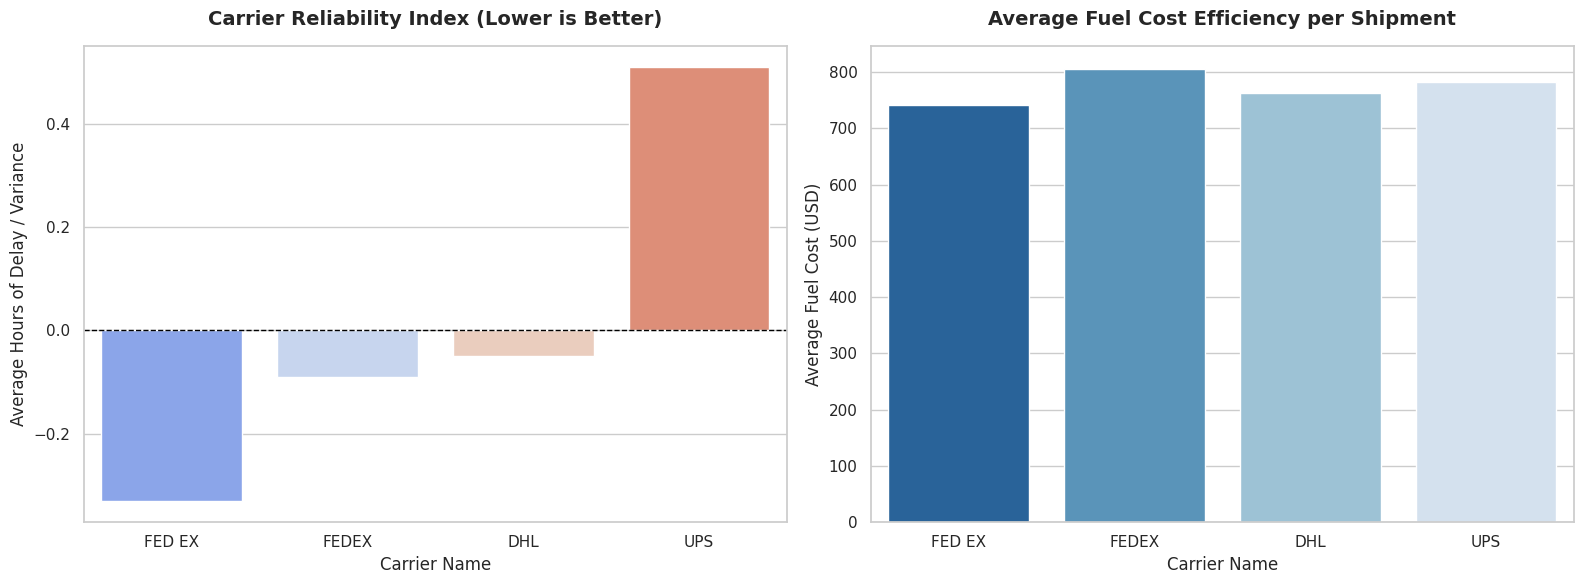

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a professional, clean visual style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 📊 Chart 1: Carrier Reliability (Average Delays)
sns.barplot(
    data=analysis_df,
    x="carrier_name",
    y="avg_hours_delay",
    palette="coolwarm",
    ax=axes[0]
)
axes[0].set_title("Carrier Reliability Index (Lower is Better)", fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel("Carrier Name", fontsize=12)
axes[0].set_ylabel("Average Hours of Delay / Variance", fontsize=12)
axes[0].axhline(0, color="black", linestyle="--", linewidth=1) # Baseline for on-time delivery

# 💰 Chart 2: Total Operating Fuel Costs by Carrier
sns.barplot(
    data=analysis_df,
    x="carrier_name",
    y="avg_fuel_cost",
    palette="Blues_r",
    ax=axes[1]
)
axes[1].set_title("Average Fuel Cost Efficiency per Shipment", fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel("Carrier Name", fontsize=12)
axes[1].set_ylabel("Average Fuel Cost (USD)", fontsize=12)

# Adjust layout spacing and render
plt.tight_layout()
plt.show()
